<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/Logo_EICT_horizontal_ESPANOL%20(1).png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:200%;color:blue;text-align:center">    <FONT COLOR="blue"> Conceptos Machine Learning </p> Ejemplo Clasificación </p> KNN (vecinos más cercanos)   </FONT>         </h1></td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Machine Learning </p></tp>
            <tp><p style="font-size:115%;text-align:center">Sem. 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>




# <FONT SIZE=5 COLOR="purple"> Ejemplo Práctico </FONT>

- En esta sección haremos un ejemplo práctico.

- Iniciaremos indicando las librerías que debemos usar.

## <FONT SIZE=4 COLOR="blue"> Librerías de trabajo </FONT>

In [1]:
# Manipulación de data.frames
import pandas       as pd
import numpy        as np

# Librerías para Gráficos
import matplotlib.pyplot  as plt
import seaborn            as sns
import plotly.express     as px

# Librerías para datos de entrenamiento y prueba
from sklearn.model_selection    import train_test_split

# Para preprocesamiento/escalar los datos
from sklearn.preprocessing      import StandardScaler, MinMaxScaler

# Para aplicar k-nearest neighbors
from sklearn.neighbors          import KNeighborsClassifier

# Métricas de evaluación
from sklearn                    import metrics
from sklearn.metrics            import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics            import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score
from imblearn.metrics           import specificity_score

# Optimización de hiperparámetros
from sklearn.model_selection    import GridSearchCV
from sklearn.model_selection    import RandomizedSearchCV

# Para ignorar los warnings
import warnings
warnings.filterwarnings("ignore")

## <FONT SIZE=4 COLOR="blue"> Contexto del problema </FONT>

En el contexto del sector financiero, las entidades emisoras de tarjetas de crédito deben tomar decisiones rápidas y precisas para determinar si un solicitante es apto o no para recibir una tarjeta, minimizando el riesgo de incumplimiento y maximizando la rentabilidad. Para ello, se analizan variables numéricas relacionadas con el perfil socioeconómico, el comportamiento crediticio y la capacidad de pago del cliente, como ingresos, nivel de endeudamiento, historial de pagos y score crediticio. Este problema se modela como una tarea de clasificación binaria en machine learning, donde el objetivo es predecir la aprobación de la tarjeta. Un modelo con alta accuracy y recall es especialmente crítico, ya que permite identificar correctamente a los buenos pagadores sin rechazar clientes solventes, apoyando decisiones automatizadas más justas, eficientes y alineadas con las políticas de riesgo de la entidad financiera.

| Variable                    | Tipo          | Descripción                                |
| --------------------------- | ------------- | ------------------------------------------ |
| `edad`                      | Entero        | Edad del solicitante (21 a 69 años)        |
| `ingreso_mensual`           | Decimal (2)   | Ingreso mensual en USD                     |
| `antiguedad_laboral_anios`  | Decimal (2)   | Años de experiencia laboral                |
| `score_crediticio`          | Entero        | Score crediticio (300 – 850)               |
| `deuda_total`               | Decimal (2)   | Total de deudas activas                    |
| `ratio_endeudamiento`       | Decimal (2)   | Deuda / Ingreso (0 a 1)                    |
| `numero_creditos_activos`   | Entero        | Créditos actualmente activos               |
| `retrasos_12m`              | Entero        | Número de retrasos en los últimos 12 meses |
| `limite_credito_solicitado` | Decimal (2)   | Monto solicitado de línea de crédito       |
| `ahorros`                   | Decimal (2)   | Monto estimado de ahorros                  |
| `aprobado`                  | Binaria (0/1) | 1 = tarjeta aprobada, 0 = rechazada        |





## <FONT SIZE=4 COLOR="blue"> Importar los datos </FONT>

Lo primero que haremos es importar los datos que están en el siguiente link o pueden ser descargados de la página de Kaggle.

https://raw.githubusercontent.com/Fabian830348/cursos/refs/heads/master/Python/credit_card_1.csv

In [2]:
credito= pd.read_csv("https://raw.githubusercontent.com/Fabian830348/cursos/refs/heads/master/Python/credit_card_1.csv")

In [3]:
credito.head()

,edad,ingreso_mensual,antiguedad_laboral_anios,score_crediticio,deuda_total,ratio_endeudamiento,numero_creditos_activos,retrasos_12m,limite_credito_solicitado,ahorros,aprobado
0,27,4961.97,17.09,525,4810.73,0.22,3,4,13944.27,5829.60,0
1,27,5120.14,18.45,720,2351.39,0.73,4,3,12074.02,10672.21,1
2,60,4517.71,18.20,843,0.00,0.47,6,0,6049.38,0.00,1
3,45,3117.94,9.41,542,9031.52,0.08,5,0,10027.23,11823.77,1
4,49,5262.63,12.25,510,5639.81,0.27,1,0,10726.52,10349.66,1


## <FONT SIZE=4 COLOR="blue"> Exploración rápida de los datos </FONT>

Se deja de ejercicio al lector

In [ ]:
credito.head

In [ ]:
credito.columns

In [ ]:
credito.info

In [ ]:
credito.describe

In [4]:
credito.aprobado.value_counts()

,count
aprobado,
0,1505
1,1495


In [10]:
fig = px.box(credito, x="edad", color="aprobado")
fig.show()

In [12]:
px.histogram(credito, x="edad")

## <FONT SIZE=4 COLOR="blue"> Modelo kNN </FONT>



----------------Matrices de confusión------------------- 




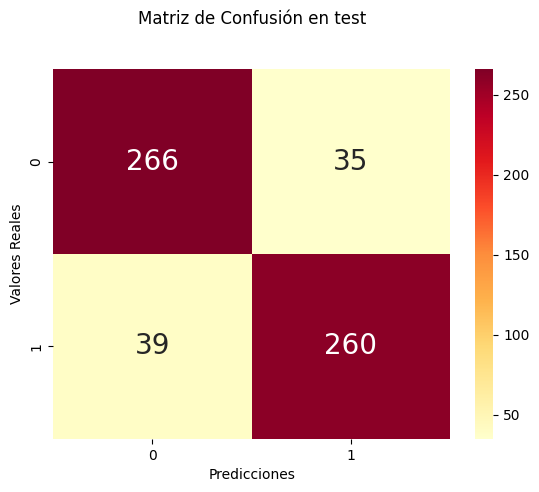

----------------Métricas de Evaluación en test------------------- 




,metrics,values
0,accuracy,0.876667
1,recall,0.869565
2,specificidad,0.883721
3,precision,0.881356
4,f1,0.875421


In [13]:
# 1. definir las variables
# la variable objetivo
y = credito["aprobado"]
# las variables predictoras
X = credito.drop("aprobado", axis=1)

# 2. Seleccionar conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,                        # variables predictoras
                                                    y,                        # variable de respuesta
                                                    stratify = y,             # garantiza que los resultados se distribuyan igual
                                                    random_state = 123,         # semilla para que al ejecutar siempre de igual
                                                    test_size = 0.2)          # tamaño del conjunto de prueba (también se puede train)
# 3. Definimos la función para escalar
escalar = StandardScaler()
# lo aplicamos a los conjuntos
X_train_s = escalar.fit_transform(X_train)
X_test_s = escalar.transform(X_test)
# 4. Definimos los modelos
modelo_knn = KNeighborsClassifier(n_neighbors = 7,         # número de vecinos k=10
                                  metric = 'euclidean',     # métrica euclideana
                                  weights= "uniform")       # peso que se asigna a los datos

# 5. Entrenamos los modelos
modelo_knn.fit(X_train_s, y_train)

# 6. Hacemos las predicciones en test en cada modelo
y_pred_knn = modelo_knn.predict(X_test_s)

print("----------------Matrices de confusión------------------- \n\n")
from sklearn                    import metrics
# from sklearn.metrics            import confusion_matrix
# 7. Hacemos las dos matrices de confusión
MC= metrics.confusion_matrix(y_test, y_pred_knn)
sns.heatmap(pd.DataFrame(MC),                    # data.frame
                annot=True,                          # colocar números de las cajitas
                annot_kws = {'size':20},             # tamaño de la letra
                cmap="YlOrRd",                       # color de la letra 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu'
                fmt='g')                             # para que salgan los número no : notación científica
plt.title('Matriz de Confusión en test', y=1.1)
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()

print("----------------Métricas de Evaluación en test------------------- \n\n")

metrics=["accuracy", "recall" , "specificidad", "precision", "f1"]
# valores
values_knn = [accuracy_score(y_test,y_pred_knn),
              recall_score(y_test,y_pred_knn),
              specificity_score(y_test,y_pred_knn),
              precision_score(y_test,y_pred_knn),
              f1_score(y_test,y_pred_knn)]

pd.DataFrame({"metrics": metrics , "values" : values_knn})




# <FONT SIZE=5 COLOR="blue"> Validación cruzada </FONT>

In [ ]:
# Validación cruzada k fold
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline        import make_pipeline

pipeline = make_pipeline(StandardScaler(), modelo_knn)

#kfold_validacion = KFold(10)                              # divide los datos en 10 pliegues.
resultados = cross_val_score(pipeline,                     # modelo aplicado
                             X,                            # conjunto de predictores
                             y,                            # variable de respuesta
                             cv = 10,                       # número de divisiones en cross-validation.
                             scoring = "accuracy")         # se puede escoger la métrica.
print(resultados)                                          # para ver la variable resultados.
resultados.mean()

[0.87666667 0.87666667 0.87333333 0.84333333 0.86       0.90333333
 0.88666667 0.92       0.87       0.92333333]


np.float64(0.8833333333333334)

# <FONT SIZE=5 COLOR="blue"> Búsqueda en grilla </FONT>

In [14]:
from sklearn.pipeline import Pipeline

# Crear pipeline con escalador y modelo
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# definimos los parámetros que vamos a combinar. Diccionario
grid_params = {"knn__n_neighbors" : list(range(1, 21)),         # se recorre la lista en k
               "knn__weights" : ["uniform","distance"],         # se establecen los pesos
               "knn__metric" : ["euclidean","manhattan"]}       # se establecen las métricas

# hacemos la búsqueda en grilla con 5-folds
Grid_Search = GridSearchCV(pipe,                                    # el modelo aplicado
                           grid_params,                             # los parámetros que van a variar
                           cv = 5,                                  # el número de folds
                           verbose = 0)                             # para que imprima resultados. Posibilidades: 1,2 o 3
# Entrenar el modelo obtenido arriba
g_res = Grid_Search.fit(X_train,y_train)

In [ ]:
print("Mejor score: ",g_res.best_score_)

Mejor score:  0.9225


In [ ]:
print("Mejores hiperparámetros", g_res.best_params_)

Mejores hiperparámetros {'knn__metric': 'euclidean', 'knn__n_neighbors': 20, 'knn__weights': 'distance'}


In [ ]:
# mejor modelo
best_model_knn = g_res.best_estimator_

# <FONT SIZE=5 COLOR="blue"> Predicción en KNN </FONT>



| Variable                    | Tipo          | Descripción                                |
| --------------------------- | ------------- | ------------------------------------------ |
| `edad`                      | 28       | Edad del solicitante (21 a 69 años)        |
| `ingreso_mensual`           | 4865  | Ingreso mensual en USD                     |
| `antiguedad_laboral_anios`  | 15  | Años de experiencia laboral                |
| `score_crediticio`          | 520      | Score crediticio (300 – 850)               |
| `deuda_total`               | 4700   | Total de deudas activas                    |
| `ratio_endeudamiento`       | 0.30   | Deuda / Ingreso (0 a 1)                    |
| `numero_creditos_activos`   | 2        | Créditos actualmente activos               |
| `retrasos_12m`              | 2        | Número de retrasos en los últimos 12 meses |
| `limite_credito_solicitado` | 11800   | Monto solicitado de línea de crédito       |
| `ahorros`                   | 6200   | Monto estimado de ahorros                  |
| `aprobado`                  | Binaria (0/1) | 1 = tarjeta aprobada, 0 = rechazada        |


Aunque el rendimiento del modelo no es el mejor, vamos a mostrar como se haría una predicción de un valor nuevo.

In [ ]:
# representamos en forma de lista
[28, 4865, 15, 520, 4700, 0.30, 2, 2, 11800, 6200]

[28, 4865, 15, 520, 4700, 0.3, 2, 2, 11800, 6200]

In [ ]:
# usamos la función escalar.transform
X_new = np.array([[28, 4865, 15, 520, 4700, 0.30, 2, 2, 11800, 6200]])
X_test1 = escalar.transform(X_new)
X_test1

array([[-1.19906905,  0.7295822 , -0.23773261, -0.35662957, -0.27241359,
        -0.88319719, -0.65349468, -0.0056375 ,  1.1599921 , -0.46637482]])

In [ ]:
best_model_knn.predict(X_test1)

array([0])

**Bonus**

A continuación, una idea de código para convertir el notebook a PDF.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!apt-get install texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!apt-get install texlive-xetex texlive-fonts-recommended texlive-generic-recommended

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [ ]:
!jupyter nbconvert --to PDF /content/drive/MyDrive/Machine_Leaning_Pre_2026_1/ Notebook_Ejercicio_Clasificacion_KNN.ipynb

[NbConvertApp] WARNING | pattern 'Notebook_Ejercicio_Clasificacion_KNN.ipynb' matched no files
[NbConvertApp] Converting notebook /content/drive/MyDrive/Machine_Leaning_Pre_2026_1/ to PDF
Traceback (most recent call last):
  File "/usr/local/bin/jupyter-nbconvert", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_core/application.py", line 284, in launch_instance
    super().launch_instance(argv=argv, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 420, in start
    self.convert_notebooks()
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 597, in convert_notebooks
    self.convert_single_notebook(notebook_filename)
  File "/usr/local/lib/python3.12/dist-packages/nbconvert/nbconvertapp.py", line 563, in convert_single_no

In [ ]:
/content/drive/MyDrive/Machine_Leaning_Pre_2026_1